# 🗳️ ElectioAnalytics — Modèle Binaire
**Algorithme :** Régression Logistique  
**Cible :** `cible_binaire` — DROITE (0) vs EXCEPTION (1)  
**Comparaison :** Version A (avec historique électoral) vs Version B (socio-éco pur)

---

## ⚙️ 0 — Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    RocCurveDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

FINAL_PATH  = 'data/final'
MODELS_PATH = 'data/models'
os.makedirs(MODELS_PATH, exist_ok=True)

# Colonnes cibles à exclure de la détection automatique des features
COLS_CIBLES = ['cible_binaire', 'cible_multiclasse', 'cible_transition_enc']

print('✅ Imports OK')

✅ Imports OK


---
## 📂 1 — Chargement des datasets

In [15]:
datasets = {}
for version in ['A', 'B']:
    train = pd.read_csv(f'{FINAL_PATH}/ml_train_2017_v{version}.csv', dtype={'code_geo': str})
    test  = pd.read_csv(f'{FINAL_PATH}/ml_test_2022_v{version}.csv',  dtype={'code_geo': str})
    features = [c for c in train.columns
                if (c.endswith('_scaled') or c.endswith('_enc'))
                and c not in COLS_CIBLES]
    datasets[version] = {'train': train, 'test': test, 'features': features}
    print(f'Version {version} — {len(features)} features : {features}')

print(f'\nTrain : {len(datasets["A"]["train"])} communes (2017)')
print(f'Test  : {len(datasets["A"]["test"])} communes (2022)')

Version A — 7 features : ['bloc_cand1_enc', 'bloc_cand2_enc', 'bloc_cand3_enc', 'bloc_cand5_enc', 'taux_faible_diplome_scaled', 'revenu_median_scaled', 'log_delinquance_scaled']
Version B — 5 features : ['taux_faible_diplome_scaled', 'revenu_median_scaled', 'log_delinquance_scaled', 'log_population_scaled', 'pct_abstention_scaled']

Train : 648 communes (2017)
Test  : 648 communes (2022)


In [16]:
# Distribution de la cible
for version in ['A', 'B']:
    y_train = datasets[version]['train']['cible_binaire'].values
    y_test  = datasets[version]['test']['cible_binaire'].values
    print(f'Version {version} — Train : DROITE={(y_train==0).sum()} / EXCEPTION={(y_train==1).sum()} '
          f'| Test : DROITE={(y_test==0).sum()} / EXCEPTION={(y_test==1).sum()}')

Version A — Train : DROITE=598 / EXCEPTION=50 | Test : DROITE=470 / EXCEPTION=178
Version B — Train : DROITE=598 / EXCEPTION=50 | Test : DROITE=470 / EXCEPTION=178


---
## 🤖 2 — Cross-Validation (k=5 stratifié)

In [17]:
resultats = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for version in ['A', 'B']:
    train    = datasets[version]['train']
    features = datasets[version]['features']
    X_train  = train[features].values
    y_train  = train['cible_binaire'].values

    model = LogisticRegression(
        class_weight='balanced',
        C=0.1,
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    )

    cv_results = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=['accuracy', 'f1', 'roc_auc'],
        return_train_score=True
    )

    resultats[version] = {
        'model': model, 'features': features,
        'cv': cv_results,
        'X_train': X_train, 'y_train': y_train
    }
    print(f'\n── Version {version} ──')
    df_cv = pd.DataFrame({
        'Métrique':  ['Accuracy', 'F1 Score', 'AUC-ROC'],
        'Train moy': [cv_results['train_accuracy'].mean(),
                      cv_results['train_f1'].mean(),
                      cv_results['train_roc_auc'].mean()],
        'Val moy':   [cv_results['test_accuracy'].mean(),
                      cv_results['test_f1'].mean(),
                      cv_results['test_roc_auc'].mean()],
        'Val std':   [cv_results['test_accuracy'].std(),
                      cv_results['test_f1'].std(),
                      cv_results['test_roc_auc'].std()],
    }).set_index('Métrique').round(3)
    df_cv['Overfit?'] = (df_cv['Train moy'] - df_cv['Val moy']).apply(
        lambda x: '⚠️ Oui' if x > 0.1 else '✅ Non'
    )
    display(df_cv)


── Version A ──


,Train moy,Val moy,Val std,Overfit?
Métrique,,,,
Accuracy,0.984,0.983,0.010,✅ Non
F1 Score,0.907,0.902,0.056,✅ Non
AUC-ROC,1.000,0.999,0.001,✅ Non



── Version B ──


,Train moy,Val moy,Val std,Overfit?
Métrique,,,,
Accuracy,0.804,0.806,0.012,✅ Non
F1 Score,0.392,0.387,0.032,✅ Non
AUC-ROC,0.862,0.846,0.064,✅ Non


---
## 🧪 3 — Évaluation sur le test 2022

In [18]:
for version in ['A', 'B']:
    train    = datasets[version]['train']
    test     = datasets[version]['test']
    features = datasets[version]['features']

    X_train = train[features].values
    y_train = train['cible_binaire'].values
    X_test  = test[features].values
    y_test  = test['cible_binaire'].values

    model = resultats[version]['model']
    model.fit(X_train, y_train)

    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    resultats[version].update({
        'y_test': y_test, 'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'acc':  accuracy_score(y_test, y_pred),
        'f1':   f1_score(y_test, y_pred),
        'auc':  roc_auc_score(y_test, y_pred_proba),
        'cm':   confusion_matrix(y_test, y_pred),
        'coefs': pd.DataFrame({
            'feature': features,
            'coefficient': model.coef_[0]
        }).sort_values('coefficient', ascending=False),
        'test_df': test.copy(),
        'X_test': X_test
    })

    joblib.dump(model, f'{MODELS_PATH}/model_binaire_v{version}.pkl')

    print(f'\n── Version {version} ──')
    print(classification_report(
        y_test, y_pred,
        target_names=['DROITE', 'EXCEPTION'],
        digits=3
    ))


── Version A ──
              precision    recall  f1-score   support

      DROITE      0.953     1.000     0.976       470
   EXCEPTION      1.000     0.871     0.931       178

    accuracy                          0.965       648
   macro avg      0.977     0.935     0.954       648
weighted avg      0.966     0.965     0.964       648


── Version B ──
              precision    recall  f1-score   support

      DROITE      0.911     0.936     0.923       470
   EXCEPTION      0.818     0.758     0.787       178

    accuracy                          0.887       648
   macro avg      0.865     0.847     0.855       648
weighted avg      0.885     0.887     0.886       648



---
## 📊 4 — Comparaison Version A vs Version B

In [19]:
df_comp = pd.DataFrame({
    'Version A': [
        f"{resultats['A']['acc']:.3f}",
        f"{resultats['A']['f1']:.3f}",
        f"{resultats['A']['auc']:.3f}",
        f"{resultats['A']['cv']['test_accuracy'].mean():.3f} ± {resultats['A']['cv']['test_accuracy'].std():.3f}"
    ],
    'Version B': [
        f"{resultats['B']['acc']:.3f}",
        f"{resultats['B']['f1']:.3f}",
        f"{resultats['B']['auc']:.3f}",
        f"{resultats['B']['cv']['test_accuracy'].mean():.3f} ± {resultats['B']['cv']['test_accuracy'].std():.3f}"
    ],
    'Écart A-B': [
        f"{resultats['A']['acc'] - resultats['B']['acc']:+.3f}",
        f"{resultats['A']['f1']  - resultats['B']['f1']:+.3f}",
        f"{resultats['A']['auc'] - resultats['B']['auc']:+.3f}",
        '—'
    ]
}, index=['Accuracy (test)', 'F1 Score (test)', 'AUC-ROC (test)', 'CV Accuracy (train)'])

print('📊 Tableau comparatif A vs B :')
display(df_comp)

ecart = resultats['A']['acc'] - resultats['B']['acc']
if ecart > 0.15:
    msg = '→ Le passé électoral est indispensable pour prédire'
elif ecart > 0.08:
    msg = '→ Le passé électoral apporte un signal significatif'
else:
    msg = '→ Les conditions socio-éco suffisent à prédire'
print(f'\n   Écart A-B : {ecart:+.3f}  {msg}')

📊 Tableau comparatif A vs B :


,Version A,Version B,Écart A-B
Accuracy (test),0.965,0.887,+0.077
F1 Score (test),0.931,0.787,+0.144
AUC-ROC (test),0.998,0.884,+0.114
CV Accuracy (train),0.983 ± 0.010,0.806 ± 0.012,—



   Écart A-B : +0.077  → Les conditions socio-éco suffisent à prédire


---
## 🟦 5 — Matrices de Confusion

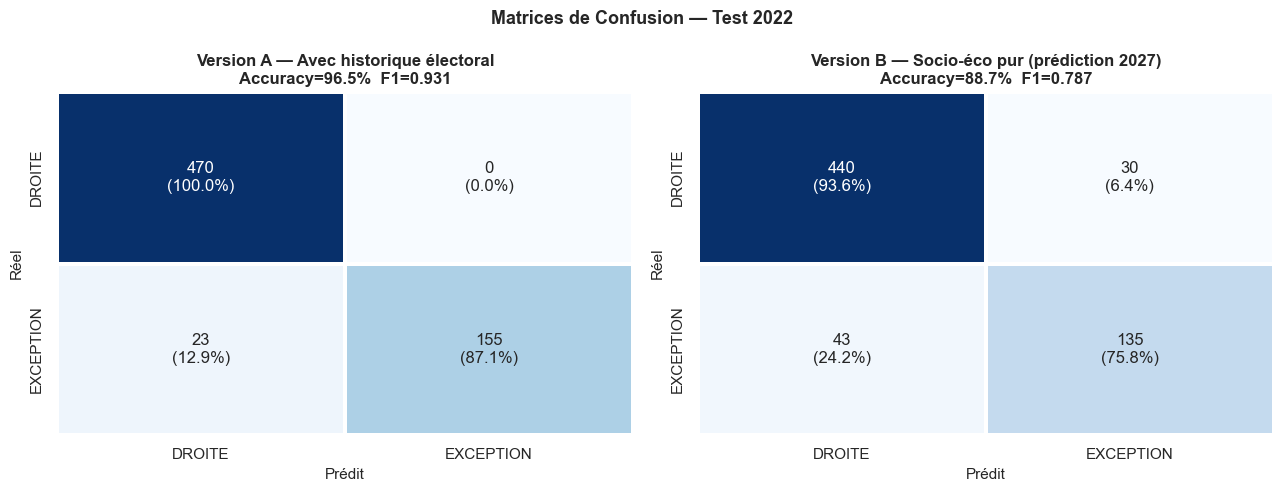

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, version in zip(axes, ['A', 'B']):
    cm     = resultats[version]['cm']
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Annotations : nombre + pourcentage
    annot = np.array([
        [f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)]
        for i in range(2)
    ])

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['DROITE', 'EXCEPTION'],
                yticklabels=['DROITE', 'EXCEPTION'],
                linewidths=1.5, cbar=False,
                annot_kws={'size': 12})

    acc = resultats[version]['acc']
    f1  = resultats[version]['f1']
    desc = 'Avec historique électoral' if version == 'A' else 'Socio-éco pur (prédiction 2027)'
    ax.set_title(f'Version {version} — {desc}\nAccuracy={acc:.1%}  F1={f1:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Prédit', fontsize=11)
    ax.set_ylabel('Réel',   fontsize=11)

plt.suptitle('Matrices de Confusion — Test 2022', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/confusion_binaire.png', dpi=120)
plt.show()

---
## 📈 6 — Courbes ROC

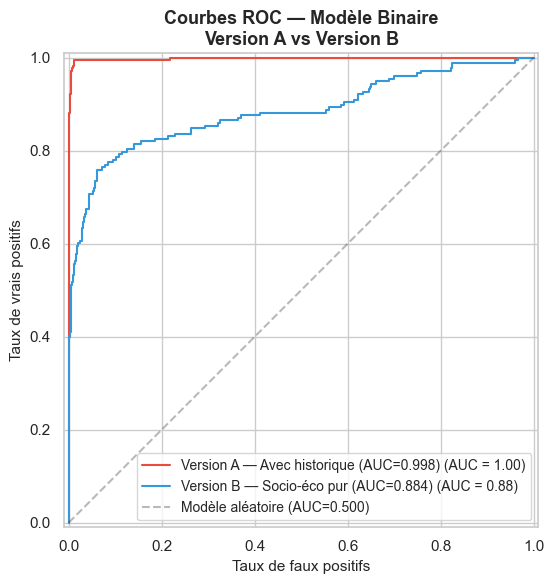

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'A': '#e74c3c', 'B': '#3498db'}
labels = {'A': 'Version A — Avec historique', 'B': 'Version B — Socio-éco pur'}

for version in ['A', 'B']:
    RocCurveDisplay.from_predictions(
        resultats[version]['y_test'],
        resultats[version]['y_pred_proba'],
        name=f"{labels[version]} (AUC={resultats[version]['auc']:.3f})",
        color=colors[version],
        ax=ax
    )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Modèle aléatoire (AUC=0.500)')
ax.set_title('Courbes ROC — Modèle Binaire\nVersion A vs Version B',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlabel('Taux de faux positifs', fontsize=11)
ax.set_ylabel('Taux de vrais positifs', fontsize=11)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/roc_binaire.png', dpi=120)
plt.show()

---
## 🔢 7 — Coefficients du modèle

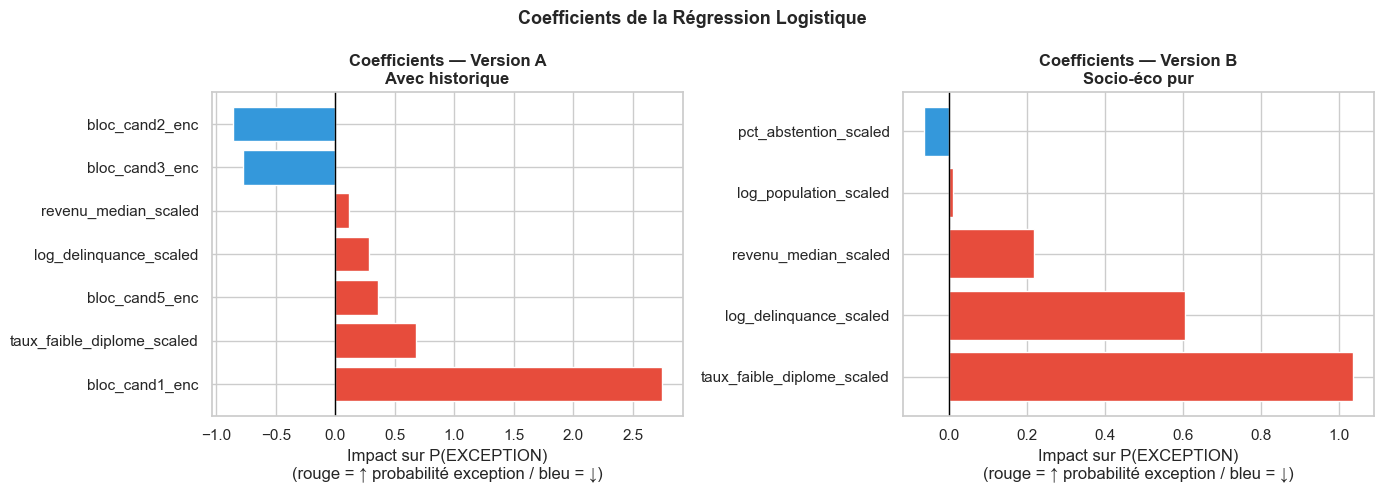


📋 Interprétation des coefficients Version B (prédiction 2027) :
   taux_faible_diplome_scaled          : +1.036 → augmente P(EXCEPTION)
   log_delinquance_scaled              : +0.605 → augmente P(EXCEPTION)
   revenu_median_scaled                : +0.219 → augmente P(EXCEPTION)
   log_population_scaled               : +0.012 → augmente P(EXCEPTION)
   pct_abstention_scaled               : -0.062 → diminue P(EXCEPTION)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, version in zip(axes, ['A', 'B']):
    coefs  = resultats[version]['coefs']
    colors = ['#e74c3c' if c > 0 else '#3498db' for c in coefs['coefficient']]
    ax.barh(coefs['feature'], coefs['coefficient'], color=colors, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=1)
    desc = 'Avec historique' if version == 'A' else 'Socio-éco pur'
    ax.set_title(f'Coefficients — Version {version}\n{desc}', fontweight='bold')
    ax.set_xlabel('Impact sur P(EXCEPTION)\n(rouge = ↑ probabilité exception / bleu = ↓)')

plt.suptitle('Coefficients de la Régression Logistique', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/coefficients_binaire.png', dpi=120)
plt.show()

print('\n📋 Interprétation des coefficients Version B (prédiction 2027) :')
for _, row in resultats['B']['coefs'].iterrows():
    sens = 'augmente' if row['coefficient'] > 0 else 'diminue'
    print(f"   {row['feature']:<35} : {row['coefficient']:+.3f} → {sens} P(EXCEPTION)")

---
## 🏙️ 8 — Probabilités de bascule par commune (Version B)

/var/folders/pg/5td0t39x2sv6xzk1jx5p5c0c0000gp/T/ipykernel_22901/3602122647.py:34: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pg/5td0t39x2sv6xzk1jx5p5c0c0000gp/T/ipykernel_22901/3602122647.py:34: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pg/5td0t39x2sv6xzk1jx5p5c0c0000gp/T/ipykernel_22901/3602122647.py:34: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pg/5td0t39x2sv6xzk1jx5p5c0c0000gp/T/ipykernel_22901/3602122647.py:34: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pg/5td0t39x2sv6xzk1jx5p5c0c0000gp/T/ipykernel_22901/3602122647.py:35: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig(f'{MODELS_PATH}/probas_communes_binaire.png', dpi=120)
/var/folders/pg/5td0t39x2sv6xzk1jx5p5c0c0000gp/T/ipy

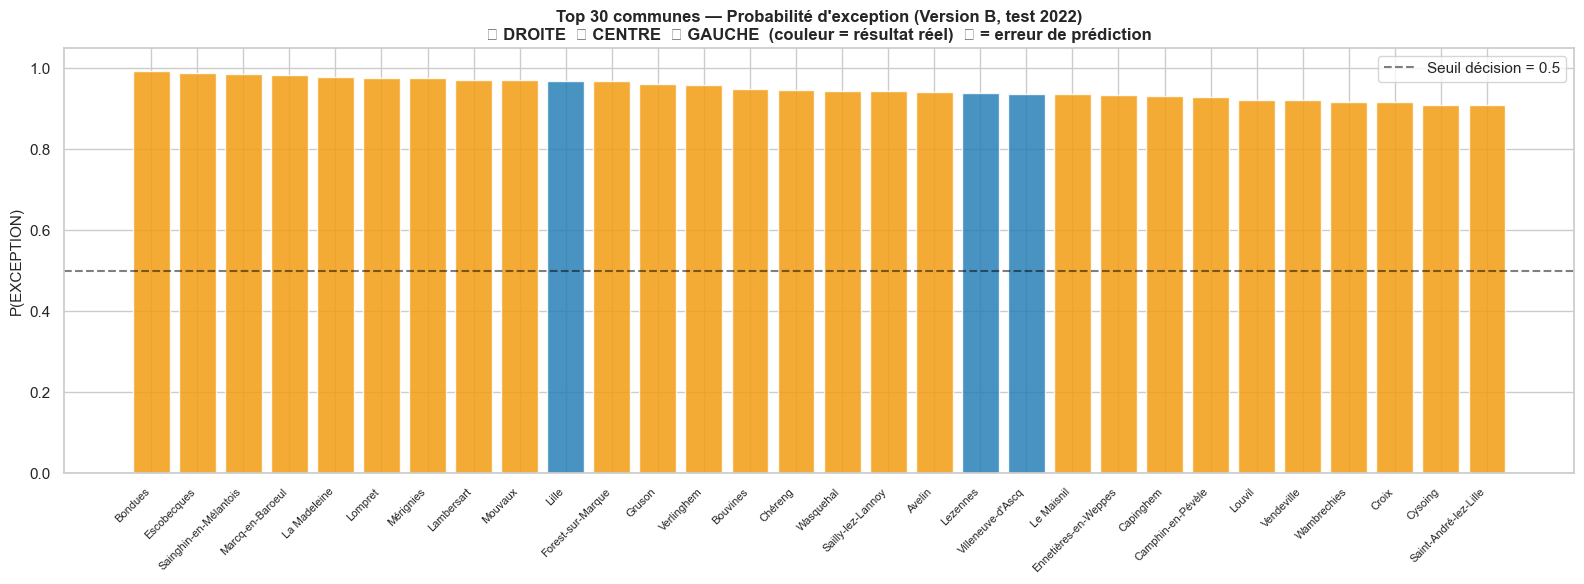

In [23]:
test_b = resultats['B']['test_df'].copy()
test_b['proba_exception'] = resultats['B']['y_pred_proba']
test_b['y_pred']          = resultats['B']['y_pred']
test_b['y_reel']          = resultats['B']['y_test']
test_b['correct']         = (test_b['y_pred'] == test_b['y_reel'])

# Top 30 communes avec la plus haute probabilité d'exception
top30 = test_b.sort_values('proba_exception', ascending=False).head(30)

couleurs = {'DROITE': '#c0392b', 'CENTRE': '#f39c12', 'GAUCHE': '#2980b9', 'DIVERS': '#7f8c8d'}
colors   = [couleurs.get(b, '#95a5a6') for b in top30['bloc_vainqueur']]

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(range(len(top30)), top30['proba_exception'],
              color=colors, alpha=0.85, edgecolor='white')

# Marquer les erreurs de prédiction
for i, (_, row) in enumerate(top30.iterrows()):
    if not row['correct']:
        ax.text(i, row['proba_exception'] + 0.01, '✗',
                ha='center', fontsize=10, color='black')

ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Seuil décision = 0.5')
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(top30['libelle_commune'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('P(EXCEPTION)', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title(
    'Top 30 communes — Probabilité d\'exception (Version B, test 2022)\n'
    '🔴 DROITE  🟠 CENTRE  🔵 GAUCHE  (couleur = résultat réel)  ✗ = erreur de prédiction',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/probas_communes_binaire.png', dpi=120)
plt.show()

---
## 🔍 9 — Analyse des erreurs (Version B)

In [24]:
faux_negatifs = test_b[(test_b['y_reel'] == 1) & (test_b['y_pred'] == 0)]
faux_positifs = test_b[(test_b['y_reel'] == 0) & (test_b['y_pred'] == 1)]

print(f'❌ Faux négatifs : {len(faux_negatifs)} communes')
print('   → Communes qui ont échappé à DROITE mais non détectées\n')
display(faux_negatifs[['libelle_commune', 'bloc_vainqueur', 'proba_exception']]
        .sort_values('proba_exception', ascending=False)
        .reset_index(drop=True))

print(f'\n⚠️  Faux positifs : {len(faux_positifs)} communes')
print('   → Communes prédites EXCEPTION mais restées DROITE\n')
display(faux_positifs[['libelle_commune', 'bloc_vainqueur', 'proba_exception']]
        .sort_values('proba_exception', ascending=False)
        .head(10)
        .reset_index(drop=True))

❌ Faux négatifs : 43 communes
   → Communes qui ont échappé à DROITE mais non détectées



,libelle_commune,bloc_vainqueur,proba_exception
0,Steenvoorde,CENTRE,0.492906
1,Don,CENTRE,0.482734
2,Saint-Jans-Cappel,CENTRE,0.460179
3,Fromelles,CENTRE,0.445482
4,Merris,CENTRE,0.438551
5,Maubeuge,GAUCHE,0.429166
6,Erquinghem-Lys,CENTRE,0.426432
7,Deûlémont,CENTRE,0.415406
8,Warlaing,CENTRE,0.397688
9,Sainte-Marie-Cappel,CENTRE,0.397377



⚠️  Faux positifs : 30 communes
   → Communes prédites EXCEPTION mais restées DROITE



,libelle_commune,bloc_vainqueur,proba_exception
0,Seclin,DROITE,0.801654
1,Eth,DROITE,0.790275
2,Beuvry-la-Forêt,DROITE,0.699488
3,Hallennes-lez-Haubourdin,DROITE,0.695470
4,Bergues,DROITE,0.679725
5,Bailleul,DROITE,0.672428
6,Thumeries,DROITE,0.655669
7,Orchies,DROITE,0.641304
8,Nieppe,DROITE,0.629707
9,Le Quesnoy,DROITE,0.625318


---
## 📋 10 — Bilan Final

In [25]:
print('=' * 60)
print('📋 BILAN MODÈLE BINAIRE — Régression Logistique')
print('=' * 60)

for version in ['A', 'B']:
    r      = resultats[version]
    cv_acc = r['cv']['test_accuracy'].mean()
    cv_std = r['cv']['test_accuracy'].std()
    desc   = 'Avec historique électoral' if version == 'A' else 'Socio-éco pur (2027)'
    print(f"""
Version {version} — {desc}
   CV Accuracy (k=5)  : {cv_acc:.3f} ± {cv_std:.3f}
   Test Accuracy 2022 : {r['acc']:.3f}  ({r['acc']*100:.1f}%)
   F1 Score           : {r['f1']:.3f}
   AUC-ROC            : {r['auc']:.3f}""")

ecart = resultats['A']['acc'] - resultats['B']['acc']
print(f"""
Écart A-B
   Accuracy : {ecart:+.3f}
   AUC-ROC  : {resultats['A']['auc'] - resultats['B']['auc']:+.3f}

Fichiers sauvegardés
   data/models/model_binaire_vA.pkl
   data/models/model_binaire_vB.pkl
   data/models/confusion_binaire.png
   data/models/roc_binaire.png
   data/models/coefficients_binaire.png
   data/models/probas_communes_binaire.png

🚀 Prochaine étape : model_multiclasse.ipynb""")

📋 BILAN MODÈLE BINAIRE — Régression Logistique

Version A — Avec historique électoral
   CV Accuracy (k=5)  : 0.983 ± 0.010
   Test Accuracy 2022 : 0.965  (96.5%)
   F1 Score           : 0.931
   AUC-ROC            : 0.998

Version B — Socio-éco pur (2027)
   CV Accuracy (k=5)  : 0.806 ± 0.012
   Test Accuracy 2022 : 0.887  (88.7%)
   F1 Score           : 0.787
   AUC-ROC            : 0.884

Écart A-B
   Accuracy : +0.077
   AUC-ROC  : +0.114

Fichiers sauvegardés
   data/models/model_binaire_vA.pkl
   data/models/model_binaire_vB.pkl
   data/models/confusion_binaire.png
   data/models/roc_binaire.png
   data/models/coefficients_binaire.png
   data/models/probas_communes_binaire.png

🚀 Prochaine étape : model_multiclasse.ipynb


Entraînement MLP en cours...


/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/L

✅ MLP — Accuracy finale sur test 2022 : 73.3%
   Max accuracy validation              : 73.3%
   Loss finale                          : 0.1592


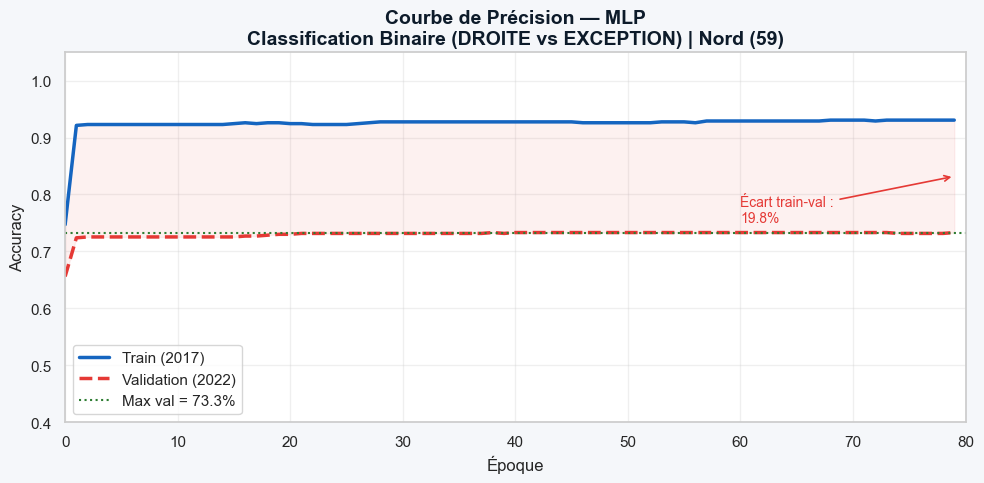

✅ Figure 1 sauvegardée → data/models/courbe_precision_binaire.png


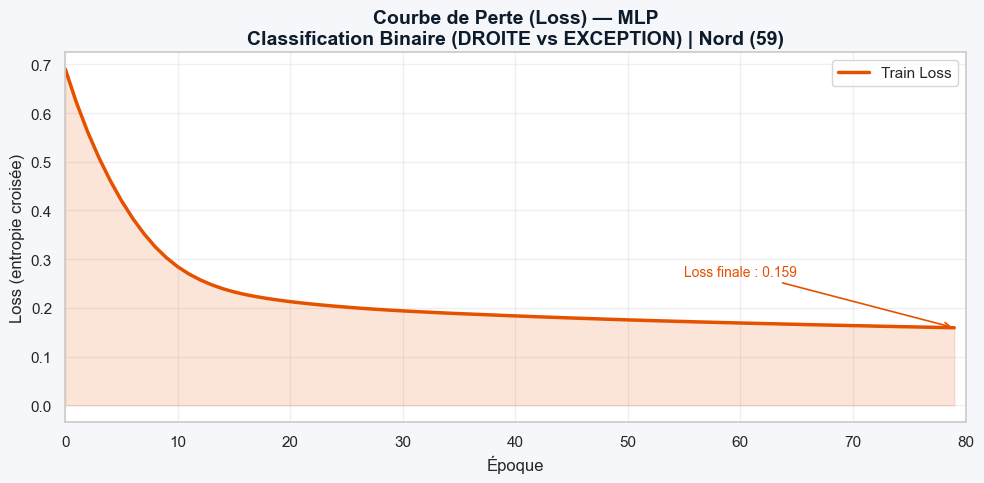

✅ Figure 2 sauvegardée → data/models/courbe_perte_binaire.png

BILAN COMPARATIF — Régression Logistique vs MLP
  Régression Logistique (Version B) : 88.7%
  MLP (Version B, epoch 80)   : 73.3%

  Interprétation :
  → La Régression Logistique reste plus stable
     (le MLP est plus puissant mais moins interprétable)

  Overfitting détecté ?
  ⚠️  Oui — écart train/val = 19.8% > 10%


In [26]:
# ================================================================
# COURBES DE PRÉCISION ET DE PERTE — model_binaire.ipynb
# À coller à la fin du notebook, après la cellule des coefficients
# ================================================================
# Le MLP génère les courbes epoch par epoch.
# On entraîne sur la VERSION B (socio-éco pur) car c'est celle
# qui sera utilisée pour prédire 2027 (sans historique électoral).
# ================================================================

from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import numpy as np

# ── Récupérer X_train / y_train / X_test / y_test de la Version B ──
# Ces variables viennent des cellules précédentes du notebook
version = 'B'
train    = datasets[version]['train']
test     = datasets[version]['test']
features = datasets[version]['features']

X_train_mlp = train[features].values
y_train_mlp = train['cible_binaire'].values
X_test_mlp  = test[features].values
y_test_mlp  = test['cible_binaire'].values

# ── Normalisation (déjà faite avant, on la refait proprement ici) ──
from sklearn.preprocessing import StandardScaler
scaler_mlp     = StandardScaler()
X_train_mlp_sc = scaler_mlp.fit_transform(X_train_mlp)
X_test_mlp_sc  = scaler_mlp.transform(X_test_mlp)

# ================================================================
# ENTRAÎNEMENT MLP EPOCH PAR EPOCH
# ================================================================
train_acc_h = []
val_acc_h   = []
loss_h      = []

mlp = MLPClassifier(
    hidden_layer_sizes  = (64, 32),   # 2 couches cachées
    activation          = 'relu',
    max_iter            = 1,          # 1 epoch à la fois
    warm_start          = True,       # conserve les poids entre appels
    random_state        = 42,
    learning_rate_init  = 0.001,
    solver              = 'adam'
)

N_EPOCHS = 80

print("Entraînement MLP en cours...")
for epoch in range(N_EPOCHS):
    mlp.fit(X_train_mlp_sc, y_train_mlp)
    train_acc_h.append(mlp.score(X_train_mlp_sc, y_train_mlp))
    val_acc_h.append(mlp.score(X_test_mlp_sc,   y_test_mlp))
    loss_h.append(mlp.loss_)

print(f"✅ MLP — Accuracy finale sur test 2022 : {val_acc_h[-1]*100:.1f}%")
print(f"   Max accuracy validation              : {max(val_acc_h)*100:.1f}%")
print(f"   Loss finale                          : {loss_h[-1]:.4f}")

# ================================================================
# FIGURE 1 — COURBE DE PRÉCISION (séparée)
# ================================================================
fig1, ax1 = plt.subplots(figsize=(10, 5))
fig1.patch.set_facecolor('#F5F7FA')

ax1.plot(train_acc_h, label='Train (2017)',      color='#1565C0', linewidth=2.5)
ax1.plot(val_acc_h,   label='Validation (2022)', color='#E53935',
         linewidth=2.5, linestyle='--')
ax1.axhline(max(val_acc_h), color='#2E7D32', linestyle=':', linewidth=1.5,
            label=f'Max val = {max(val_acc_h)*100:.1f}%')
ax1.fill_between(range(N_EPOCHS), train_acc_h, val_acc_h,
                 alpha=0.07, color='#E53935')

# Annotation du gap train/val
gap = train_acc_h[-1] - val_acc_h[-1]
ax1.annotate(f'Écart train-val :\n{gap*100:.1f}%',
             xy=(N_EPOCHS-1, (train_acc_h[-1]+val_acc_h[-1])/2),
             xytext=(N_EPOCHS-20, (train_acc_h[-1]+val_acc_h[-1])/2 - 0.08),
             fontsize=10, color='#E53935',
             arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.2))

ax1.set_title('Courbe de Précision — MLP\nClassification Binaire (DROITE vs EXCEPTION) | Nord (59)',
              fontsize=14, fontweight='bold', color='#0D1B2A')
ax1.set_xlabel('Époque', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.4, 1.05)
ax1.set_xlim(0, N_EPOCHS)

plt.tight_layout()
plt.savefig('data/models/courbe_precision_binaire.png',
            dpi=160, bbox_inches='tight', facecolor='#F5F7FA')
plt.show()
print("✅ Figure 1 sauvegardée → data/models/courbe_precision_binaire.png")

# ================================================================
# FIGURE 2 — COURBE DE PERTE (séparée)
# ================================================================
fig2, ax2 = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor('#F5F7FA')

ax2.plot(loss_h, color='#E65100', linewidth=2.5, label='Train Loss')
ax2.fill_between(range(N_EPOCHS), loss_h, alpha=0.15, color='#E65100')

# Annotation perte finale
ax2.annotate(f'Loss finale : {loss_h[-1]:.3f}',
             xy=(N_EPOCHS-1, loss_h[-1]),
             xytext=(N_EPOCHS-25, loss_h[-1] + (loss_h[0]-loss_h[-1])*0.2),
             fontsize=10, color='#E65100',
             arrowprops=dict(arrowstyle='->', color='#E65100', lw=1.2))

ax2.set_title('Courbe de Perte (Loss) — MLP\nClassification Binaire (DROITE vs EXCEPTION) | Nord (59)',
              fontsize=14, fontweight='bold', color='#0D1B2A')
ax2.set_xlabel('Époque', fontsize=12)
ax2.set_ylabel('Loss (entropie croisée)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, N_EPOCHS)

plt.tight_layout()
plt.savefig('data/models/courbe_perte_binaire.png',
            dpi=160, bbox_inches='tight', facecolor='#F5F7FA')
plt.show()
print("✅ Figure 2 sauvegardée → data/models/courbe_perte_binaire.png")

# ================================================================
# BILAN MLP vs Régression Logistique
# ================================================================
print("\n" + "="*55)
print("BILAN COMPARATIF — Régression Logistique vs MLP")
print("="*55)
print(f"  Régression Logistique (Version B) : {resultats['B']['acc']*100:.1f}%")
print(f"  MLP (Version B, epoch {N_EPOCHS})   : {val_acc_h[-1]*100:.1f}%")
print(f"\n  Interprétation :")
if val_acc_h[-1] > resultats['B']['acc']:
    print(f"  → Le MLP fait mieux de "
          f"{(val_acc_h[-1]-resultats['B']['acc'])*100:.1f} points")
else:
    print(f"  → La Régression Logistique reste plus stable")
    print(f"     (le MLP est plus puissant mais moins interprétable)")
print(f"\n  Overfitting détecté ?")
gap_final = train_acc_h[-1] - val_acc_h[-1]
if gap_final > 0.1:
    print(f"  ⚠️  Oui — écart train/val = {gap_final*100:.1f}% > 10%")
else:
    print(f"  ✅ Non — écart train/val = {gap_final*100:.1f}% ≤ 10%")

In [27]:
# Imports requis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay, classification_report

# Palette personnalisable (modifier les couleurs ici)
PALETTE = {
    'bg': '#F5F7FA',
    'acc_bar': '#1565C0',
    'roc_A': '#e74c3c',
    'roc_B': '#3498db',
    'hist_pos': '#2ecc71',
    'hist_neg': '#E53935',
    'cm_cmap': 'Blues'
}

def plot_confusion_matrix(y_true, y_pred, labels=['Perdant','Gagnant'], title='Matrice de confusion'):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(cm.shape[1])] for i in range(cm.shape[0])])
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=annot, fmt='', cmap=PALETTE['cm_cmap'], cbar=False,
                xticklabels=labels, yticklabels=labels, linewidths=1.0, annot_kws={'size':12})
    plt.xlabel('Prédit'); plt.ylabel('Réel'); plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_roc(y_true, y_prob, label='Modèle', color='#1565C0', title='Courbe ROC'):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'k--', alpha=0.3)
    plt.xlabel('Taux de faux positifs'); plt.ylabel('Taux de vrais positifs')
    plt.title(title); plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_proba_histograms(y_true, y_prob, bins=20, title='Distribution des probabilités'):
    plt.figure(figsize=(8,4))
    plt.hist(y_prob[y_true==1], bins=bins, alpha=0.7, color=PALETTE['hist_pos'], label='Gagnant (1)')
    plt.hist(y_prob[y_true==0], bins=bins, alpha=0.6, color=PALETTE['hist_neg'], label='Perdant (0)')
    plt.axvline(0.5, color='k', linestyle='--', alpha=0.6)
    plt.xlabel('P(pred=1)'); plt.ylabel('Fréquence')
    plt.title(title); plt.legend()
    plt.tight_layout()
    plt.show()

def plot_feature_importance_or_coefs(model, feature_names, top_n=15, title='Importance des features'):
    plt.figure(figsize=(8, max(4, 0.3*len(feature_names))))
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
        df = sorted(zip(feature_names, imp), key=lambda x: x[1], reverse=True)[:top_n]
        names, vals = zip(*df)
        sns.barplot(x=list(vals), y=list(names), palette='viridis')
        plt.xlabel('Importance (Gini)')
    elif hasattr(model, 'coef_'):
        coefs = model.coef_[0]
        df = sorted(zip(feature_names, coefs), key=lambda x: abs(x[1]), reverse=True)[:top_n]
        names, vals = zip(*df)
        colors = ['#e74c3c' if v>0 else '#3498db' for v in vals]
        plt.barh(names, vals, color=colors)
        plt.xlabel('Coefficient (impact sur P(EXCEPTION))')
    else:
        plt.text(0.5, 0.5, 'Pas d\'importances disponibles pour ce modèle', ha='center')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Exemple d'utilisation (adapté au notebook `model_binaire.ipynb`):
# r = resultats['B']  # ou 'A'
# plot_confusion_matrix(r['y_test'], r['y_pred'], labels=['DROITE','EXCEPTION'], title='Confusion — Version B')
# plot_roc(r['y_test'], r['y_pred_proba'], label='Version B', color=PALETTE['roc_B'])
# plot_proba_histograms(r['y_test'], r['y_pred_proba'])
# plot_feature_importance_or_coefs(r['model'], resultats['B']['features'])

Entraînement MLP binaire...


/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/L

✅ MLP — Accuracy test 2022 : 73.3%


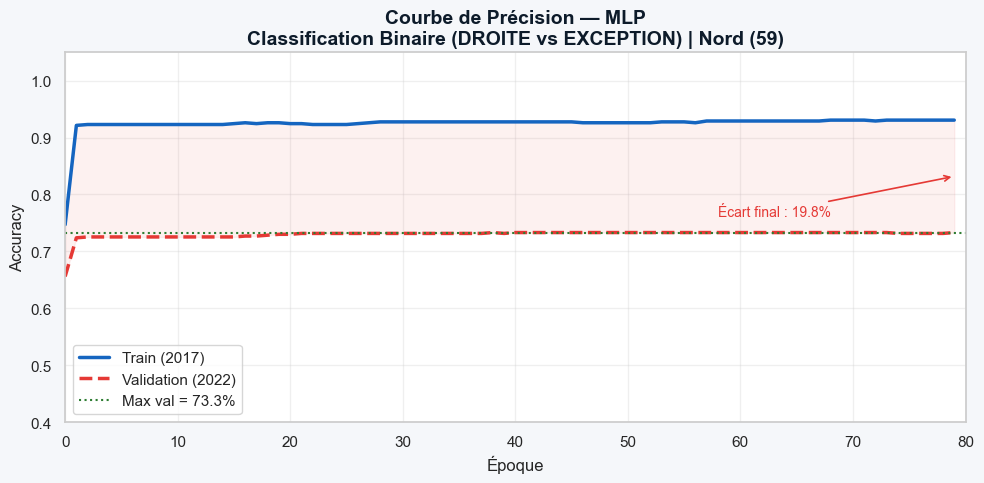

✅ Figure 1 — Courbe de précision


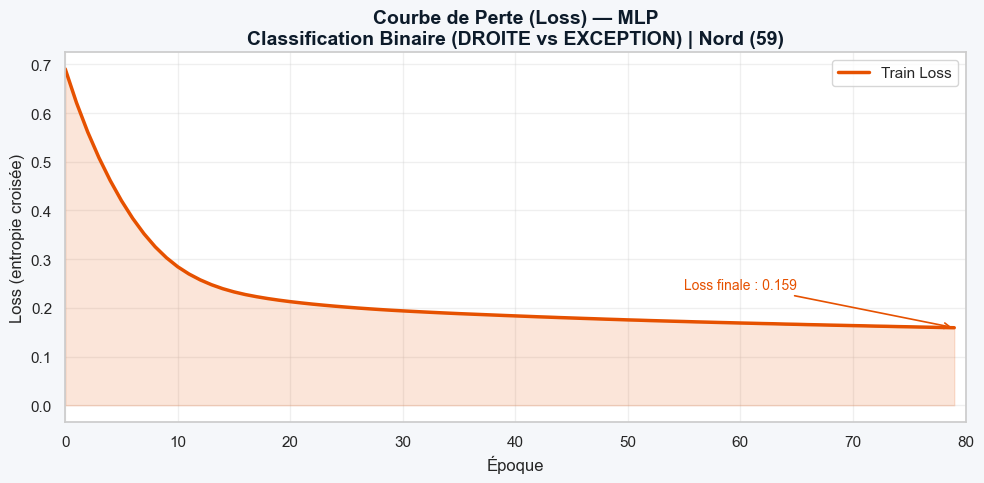

✅ Figure 2 — Courbe de perte


/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
  

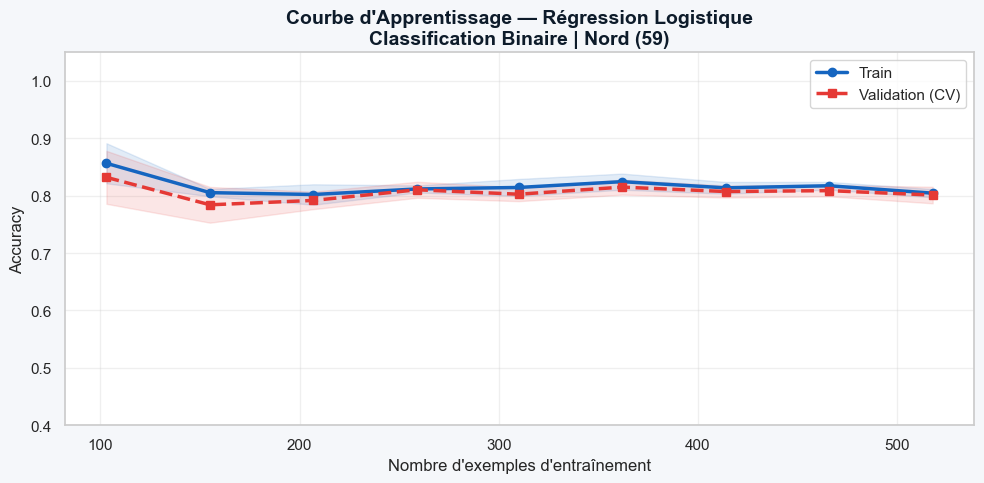

✅ Figure 3 — Courbe d'apprentissage


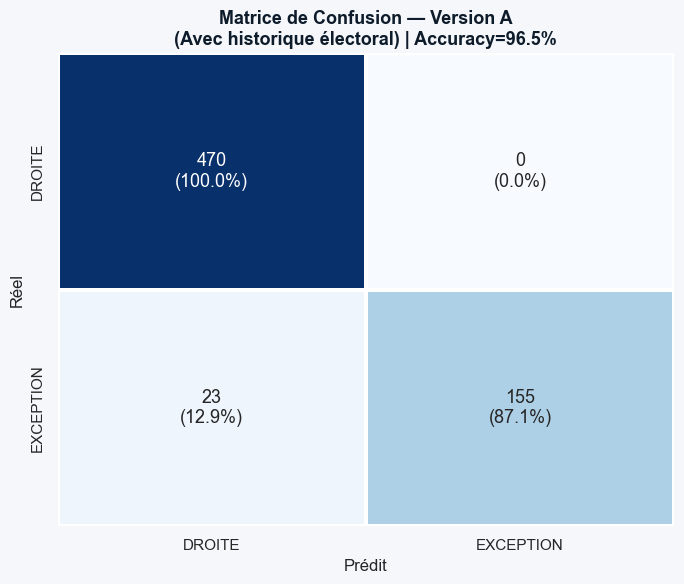

✅ Figure 4 — Matrice confusion Version A


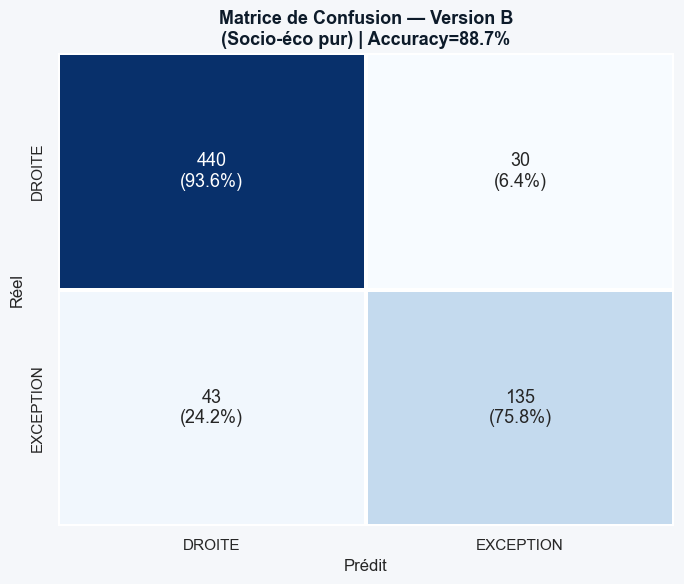

✅ Figure 5 — Matrice confusion Version B


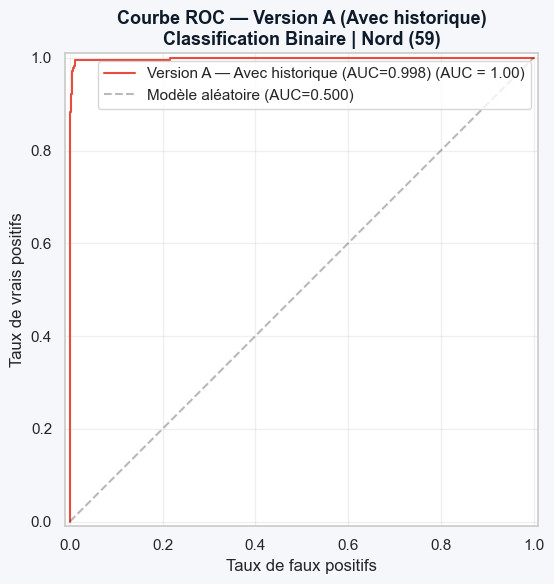

✅ Figure 6 — Courbe ROC Version A


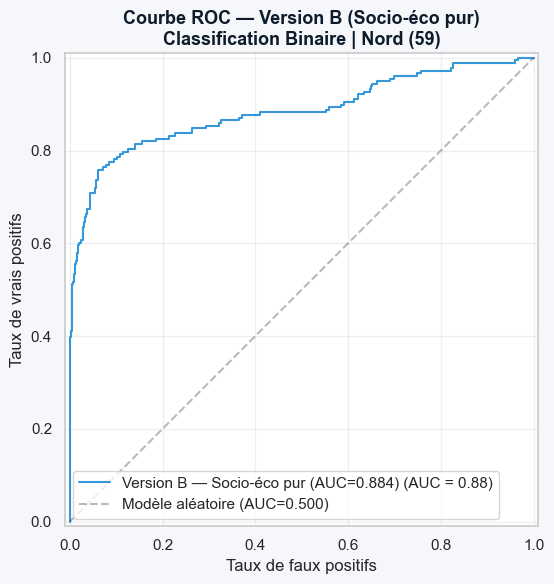

✅ Figure 7 — Courbe ROC Version B


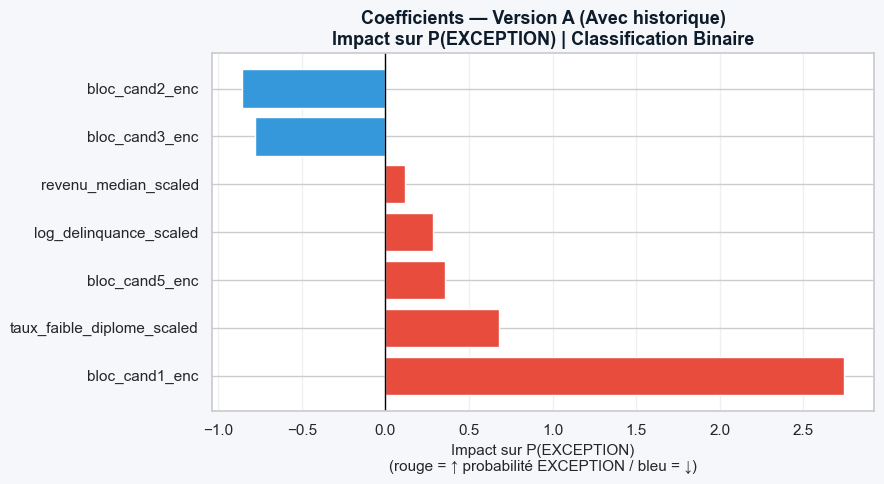

✅ Figure 8 — Coefficients Version A


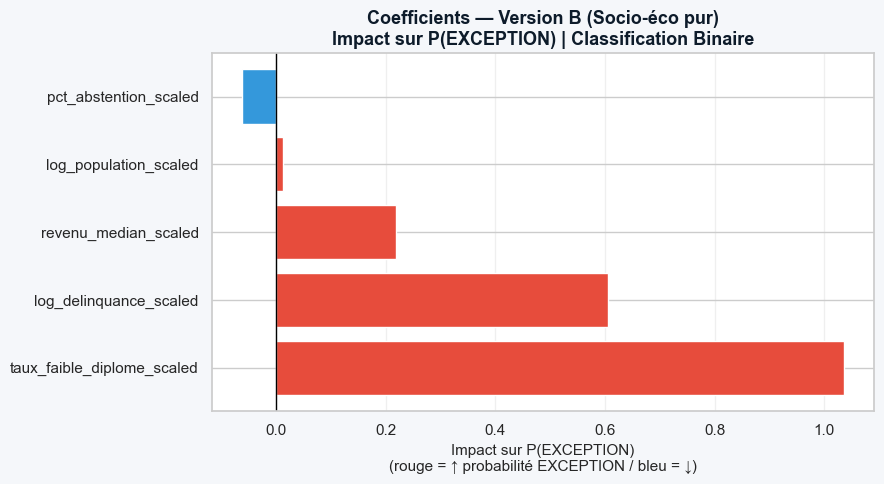

✅ Figure 9 — Coefficients Version B


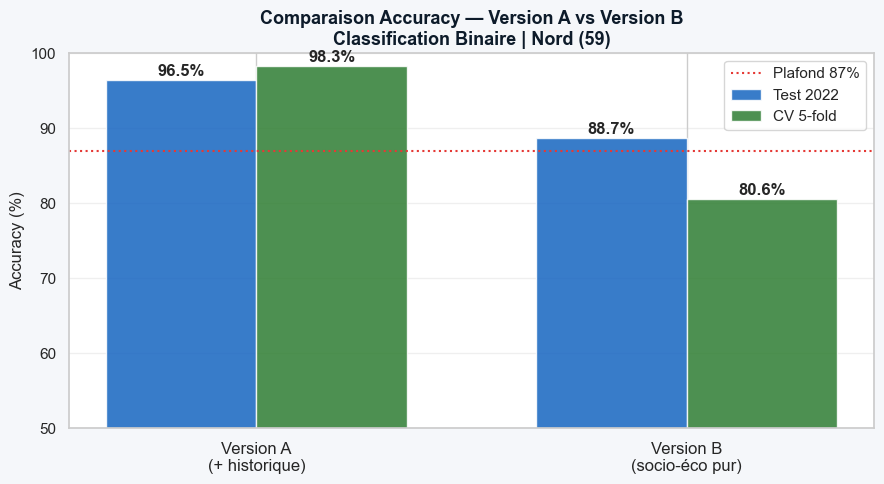

✅ Figure 10 — Comparaison Version A vs B

📋 BILAN — Toutes les figures générées
  ✅ bin_fig1_courbe_precision.png            — Courbe de précision MLP
  ✅ bin_fig2_courbe_perte.png                — Courbe de perte MLP
  ✅ bin_fig3_courbe_apprentissage.png        — Courbe d'apprentissage LR
  ✅ bin_fig4_confusion_vA.png                — Matrice confusion Version A
  ✅ bin_fig5_confusion_vB.png                — Matrice confusion Version B
  ✅ bin_fig6_roc_vA.png                      — Courbe ROC Version A
  ✅ bin_fig7_roc_vB.png                      — Courbe ROC Version B
  ✅ bin_fig8_coefs_vA.png                    — Coefficients Version A
  ✅ bin_fig9_coefs_vB.png                    — Coefficients Version B
  ✅ bin_fig10_comparaison_vA_vB.png          — Comparaison A vs B

Tout sauvegardé dans : data/models/


In [28]:
# ================================================================
# TOUTES LES COURBES — model_binaire.ipynb
# Chaque graphique dans sa propre figure séparée
# À coller dans une nouvelle cellule à la fin du notebook
# ================================================================

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs(MODELS_PATH, exist_ok=True)

NAVY  = "#0D1B2A"
BLUE  = "#1565C0"
RED   = "#E53935"
GREEN = "#2E7D32"
GOLD  = "#FFB300"
ORANGE= "#E65100"

# ================================================================
# PRÉPARATION DES DONNÉES MLP (Version B — socio-éco pur)
# ================================================================
version  = 'B'
train_b  = datasets[version]['train']
test_b   = datasets[version]['test']
features = datasets[version]['features']

X_train_b = train_b[features].values
y_train_b = train_b['cible_binaire'].values
X_test_b  = test_b[features].values
y_test_b  = test_b['cible_binaire'].values

# ── MLP entraîné epoch par epoch ──────────────────────────────
train_acc_h, val_acc_h, loss_h = [], [], []

mlp = MLPClassifier(
    hidden_layer_sizes = (64, 32),
    activation         = 'relu',
    max_iter           = 1,
    warm_start         = True,
    random_state       = 42,
    learning_rate_init = 0.001,
    solver             = 'adam'
)

N_EPOCHS = 80
print("Entraînement MLP binaire...")
for _ in range(N_EPOCHS):
    mlp.fit(X_train_b, y_train_b)
    train_acc_h.append(mlp.score(X_train_b, y_train_b))
    val_acc_h.append(mlp.score(X_test_b,   y_test_b))
    loss_h.append(mlp.loss_)

print(f"✅ MLP — Accuracy test 2022 : {val_acc_h[-1]*100:.1f}%")

# ================================================================
# FIGURE 1 — Courbe de Précision MLP (Train vs Validation)
# ================================================================
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F5F7FA')

ax.plot(train_acc_h, label='Train (2017)',       color=BLUE,  linewidth=2.5)
ax.plot(val_acc_h,   label='Validation (2022)',  color=RED,   linewidth=2.5, linestyle='--')
ax.axhline(max(val_acc_h), color=GREEN, linestyle=':', linewidth=1.5,
           label=f'Max val = {max(val_acc_h)*100:.1f}%')
ax.fill_between(range(N_EPOCHS), train_acc_h, val_acc_h, alpha=0.07, color=RED)

gap = train_acc_h[-1] - val_acc_h[-1]
ax.annotate(f'Écart final : {gap*100:.1f}%',
            xy=(N_EPOCHS-1, (train_acc_h[-1]+val_acc_h[-1])/2),
            xytext=(N_EPOCHS-22, (train_acc_h[-1]+val_acc_h[-1])/2 - 0.07),
            fontsize=10, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

ax.set_title('Courbe de Précision — MLP\nClassification Binaire (DROITE vs EXCEPTION) | Nord (59)',
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_xlabel('Époque', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)
ax.set_xlim(0, N_EPOCHS)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/bin_fig1_courbe_precision.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 1 — Courbe de précision")

# ================================================================
# FIGURE 2 — Courbe de Perte MLP
# ================================================================
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F5F7FA')

ax.plot(loss_h, color=ORANGE, linewidth=2.5, label='Train Loss')
ax.fill_between(range(N_EPOCHS), loss_h, alpha=0.15, color=ORANGE)
ax.annotate(f'Loss finale : {loss_h[-1]:.3f}',
            xy=(N_EPOCHS-1, loss_h[-1]),
            xytext=(N_EPOCHS-25, loss_h[-1] + (loss_h[0]-loss_h[-1])*0.15),
            fontsize=10, color=ORANGE,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2))

ax.set_title('Courbe de Perte (Loss) — MLP\nClassification Binaire (DROITE vs EXCEPTION) | Nord (59)',
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_xlabel('Époque', fontsize=12)
ax.set_ylabel('Loss (entropie croisée)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, N_EPOCHS)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/bin_fig2_courbe_perte.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 2 — Courbe de perte")

# ================================================================
# FIGURE 3 — Courbe d'Apprentissage Random Forest (learning_curve)
# ================================================================
ts, tr_sc, val_sc = learning_curve(
    resultats['B']['model'],
    X_train_b, y_train_b, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F5F7FA')

ax.plot(ts, tr_sc.mean(1),  label='Train',          color=BLUE, linewidth=2.5, marker='o')
ax.plot(ts, val_sc.mean(1), label='Validation (CV)', color=RED,  linewidth=2.5,
        linestyle='--', marker='s')
ax.fill_between(ts, tr_sc.mean(1)-tr_sc.std(1),  tr_sc.mean(1)+tr_sc.std(1),  alpha=0.12, color=BLUE)
ax.fill_between(ts, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1), alpha=0.12, color=RED)

ax.set_title("Courbe d'Apprentissage — Régression Logistique\nClassification Binaire | Nord (59)",
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_xlabel("Nombre d'exemples d'entraînement", fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/bin_fig3_courbe_apprentissage.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 3 — Courbe d'apprentissage")

# ================================================================
# FIGURE 4 — Matrice de Confusion Version A (séparée)
# ================================================================
import seaborn as sns

cm_a     = resultats['A']['cm']
cm_a_pct = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True) * 100
annot_a  = np.array([[f"{cm_a[i,j]}\n({cm_a_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#F5F7FA')
sns.heatmap(cm_a, annot=annot_a, fmt='', cmap='Blues', ax=ax,
            xticklabels=['DROITE','EXCEPTION'],
            yticklabels=['DROITE','EXCEPTION'],
            linewidths=1.5, cbar=False, annot_kws={'size': 13})
ax.set_title(f"Matrice de Confusion — Version A\n(Avec historique électoral) | Accuracy={resultats['A']['acc']:.1%}",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_ylabel('Réel', fontsize=12)
ax.set_xlabel('Prédit', fontsize=12)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/bin_fig4_confusion_vA.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 4 — Matrice confusion Version A")

# ================================================================
# FIGURE 5 — Matrice de Confusion Version B (séparée)
# ================================================================
cm_b     = resultats['B']['cm']
cm_b_pct = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True) * 100
annot_b  = np.array([[f"{cm_b[i,j]}\n({cm_b_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#F5F7FA')
sns.heatmap(cm_b, annot=annot_b, fmt='', cmap='Blues', ax=ax,
            xticklabels=['DROITE','EXCEPTION'],
            yticklabels=['DROITE','EXCEPTION'],
            linewidths=1.5, cbar=False, annot_kws={'size': 13})
ax.set_title(f"Matrice de Confusion — Version B\n(Socio-éco pur) | Accuracy={resultats['B']['acc']:.1%}",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_ylabel('Réel', fontsize=12)
ax.set_xlabel('Prédit', fontsize=12)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/bin_fig5_confusion_vB.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 5 — Matrice confusion Version B")

# ================================================================
# FIGURE 6 — Courbe ROC Version A (séparée)
# ================================================================
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F5F7FA')
RocCurveDisplay.from_predictions(
    resultats['A']['y_test'], resultats['A']['y_pred_proba'],
    name=f"Version A — Avec historique (AUC={resultats['A']['auc']:.3f})",
    color='#e74c3c', ax=ax)
ax.plot([0,1],[0,1], 'k--', alpha=0.3, label='Modèle aléatoire (AUC=0.500)')
ax.set_title("Courbe ROC — Version A (Avec historique)\nClassification Binaire | Nord (59)",
             fontsize=13, fontweight='bold', color=NAVY)
ax.legend(fontsize=11)
ax.set_xlabel('Taux de faux positifs', fontsize=12)
ax.set_ylabel('Taux de vrais positifs', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/bin_fig6_roc_vA.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 6 — Courbe ROC Version A")

# ================================================================
# FIGURE 7 — Courbe ROC Version B (séparée)
# ================================================================
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F5F7FA')
RocCurveDisplay.from_predictions(
    resultats['B']['y_test'], resultats['B']['y_pred_proba'],
    name=f"Version B — Socio-éco pur (AUC={resultats['B']['auc']:.3f})",
    color='#3498db', ax=ax)
ax.plot([0,1],[0,1], 'k--', alpha=0.3, label='Modèle aléatoire (AUC=0.500)')
ax.set_title("Courbe ROC — Version B (Socio-éco pur)\nClassification Binaire | Nord (59)",
             fontsize=13, fontweight='bold', color=NAVY)
ax.legend(fontsize=11)
ax.set_xlabel('Taux de faux positifs', fontsize=12)
ax.set_ylabel('Taux de vrais positifs', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/bin_fig7_roc_vB.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 7 — Courbe ROC Version B")

# ================================================================
# FIGURE 8 — Coefficients Version A (séparée)
# ================================================================
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F5F7FA')
coefs_a = resultats['A']['coefs']
colors_c = ['#e74c3c' if c > 0 else '#3498db' for c in coefs_a['coefficient']]
ax.barh(coefs_a['feature'], coefs_a['coefficient'], color=colors_c, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title("Coefficients — Version A (Avec historique)\nImpact sur P(EXCEPTION) | Classification Binaire",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Impact sur P(EXCEPTION)\n(rouge = ↑ probabilité EXCEPTION / bleu = ↓)', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/bin_fig8_coefs_vA.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 8 — Coefficients Version A")

# ================================================================
# FIGURE 9 — Coefficients Version B (séparée)
# ================================================================
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F5F7FA')
coefs_b = resultats['B']['coefs']
colors_c = ['#e74c3c' if c > 0 else '#3498db' for c in coefs_b['coefficient']]
ax.barh(coefs_b['feature'], coefs_b['coefficient'], color=colors_c, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title("Coefficients — Version B (Socio-éco pur)\nImpact sur P(EXCEPTION) | Classification Binaire",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Impact sur P(EXCEPTION)\n(rouge = ↑ probabilité EXCEPTION / bleu = ↓)', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/bin_fig9_coefs_vB.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 9 — Coefficients Version B")

# ================================================================
# FIGURE 10 — Comparaison Accuracy Version A vs B
# ================================================================
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F5F7FA')

versions  = ['Version A\n(+ historique)', 'Version B\n(socio-éco pur)']
accs_test = [resultats['A']['acc']*100, resultats['B']['acc']*100]
accs_cv_a = resultats['A']['cv']['test_accuracy'].mean()*100
accs_cv_b = resultats['B']['cv']['test_accuracy'].mean()*100
accs_cv   = [accs_cv_a, accs_cv_b]

x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, accs_test, w, label='Test 2022',  color=BLUE,  alpha=0.85)
b2 = ax.bar(x + w/2, accs_cv,   w, label='CV 5-fold',  color=GREEN, alpha=0.85)
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f"{b.get_height():.1f}%", ha='center', fontsize=12, fontweight='bold')

ax.axhline(87, color=RED, linestyle=':', linewidth=1.5, label='Plafond 87%')
ax.set_title("Comparaison Accuracy — Version A vs Version B\nClassification Binaire | Nord (59)",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_xticks(x)
ax.set_xticklabels(versions, fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(50, 100)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/bin_fig10_comparaison_vA_vB.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 10 — Comparaison Version A vs B")

# ================================================================
# BILAN
# ================================================================
print(f"\n{'='*55}")
print("📋 BILAN — Toutes les figures générées")
print(f"{'='*55}")
figures = [
    ("bin_fig1_courbe_precision.png",     "Courbe de précision MLP"),
    ("bin_fig2_courbe_perte.png",          "Courbe de perte MLP"),
    ("bin_fig3_courbe_apprentissage.png",  "Courbe d'apprentissage LR"),
    ("bin_fig4_confusion_vA.png",          "Matrice confusion Version A"),
    ("bin_fig5_confusion_vB.png",          "Matrice confusion Version B"),
    ("bin_fig6_roc_vA.png",                "Courbe ROC Version A"),
    ("bin_fig7_roc_vB.png",                "Courbe ROC Version B"),
    ("bin_fig8_coefs_vA.png",              "Coefficients Version A"),
    ("bin_fig9_coefs_vB.png",              "Coefficients Version B"),
    ("bin_fig10_comparaison_vA_vB.png",    "Comparaison A vs B"),
]
for fname, desc in figures:
    print(f"  ✅ {fname:<40} — {desc}")
print(f"\nTout sauvegardé dans : {MODELS_PATH}/")